In [ ]:
import mysql.connector
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

conn = mysql.connector.connect(
    host='127.0.0.1',
    port=3307,
    user='lichess',
    password='Lichess_Analytics1!',
    database='lichess_analytics',
    collation='utf8mb4_unicode_ci'
)

cursor = conn.cursor()
cursor.execute("SHOW TABLES;")
print(cursor.fetchall())

[('batch_predictions',), ('dim_date',), ('dim_opening',), ('dim_player',), ('fact_games',), ('inference_runs',), ('prediction_logs',)]


In [ ]:
cursor.execute("DESCRIBE fact_games;")
for row in cursor.fetchall():
    print(row)

('game_id', 'varchar(32)', 'NO', '', None, '')
('white_player_id', 'varchar(32)', 'YES', '', None, '')
('black_player_id', 'varchar(32)', 'YES', '', None, '')
('opening_id', 'varchar(32)', 'YES', '', None, '')
('date_id', 'int(11)', 'YES', '', None, '')
('result', 'varchar(16)', 'YES', '', None, '')
('white_elo', 'int(11)', 'YES', '', None, '')
('black_elo', 'int(11)', 'YES', '', None, '')
('white_rating_diff', 'int(11)', 'YES', '', None, '')
('black_rating_diff', 'int(11)', 'YES', '', None, '')
('time_control', 'varchar(64)', 'YES', '', None, '')
('termination', 'varchar(64)', 'YES', '', None, '')
('event', 'varchar(255)', 'YES', '', None, '')
('utc_datetime', 'varchar(32)', 'YES', '', None, '')
('move_count', 'int(11)', 'YES', '', None, '')
('year', 'int(11)', 'NO', '', None, '')
('month', 'int(11)', 'NO', '', None, '')


In [ ]:
for table in ['dim_player', 'dim_opening', 'dim_date']:
    cursor.execute(f"DESCRIBE {table};")
    print(f"\nColumn info for {table}:")
    for row in cursor.fetchall():
        print(row)


Column info for dim_player:
('player_id', 'varchar(32)', 'NO', '', None, '')
('username', 'varchar(255)', 'YES', '', None, '')
('title', 'varchar(16)', 'YES', '', None, '')
('last_known_elo', 'int(11)', 'YES', '', None, '')

Column info for dim_opening:
('opening_id', 'varchar(32)', 'NO', '', None, '')
('eco', 'varchar(16)', 'YES', '', None, '')
('opening_name', 'varchar(512)', 'YES', '', None, '')

Column info for dim_date:
('date_id', 'int(11)', 'NO', '', None, '')
('calendar_date', 'date', 'YES', '', None, '')
('year', 'int(11)', 'YES', '', None, '')
('month', 'int(11)', 'YES', '', None, '')
('day_of_week', 'int(11)', 'YES', '', None, '')


# Missing Values

In [ ]:
tables = ['fact_games', 'dim_player', 'dim_opening', 'batch_predictions']
for table in tables:
    query = f"SELECT COUNT(*) as total FROM {table}"
    cursor.execute(query)
    total = cursor.fetchone()[0]
    
    if table == 'fact_games':
        cursor.execute(f"SELECT COUNT(*) FROM {table} WHERE white_elo IS NULL OR black_elo IS NULL")
        missing_elo = cursor.fetchone()[0]
        print(f"{table}: {missing_elo}/{total} rows missing rating")
    elif table == 'batch_predictions':
        cursor.execute(f"SELECT COUNT(*) FROM {table} WHERE player_elo IS NULL")
        missing_elo = cursor.fetchone()[0]
        print(f"{table}: {missing_elo}/{total} rows missing player_elo")

fact_games: 218/121332 rows missing rating
batch_predictions: 4400/4400 rows missing player_elo


# Outlier detection

/tmp/ipykernel_268276/4160402406.py:3: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  ratings = pd.read_sql(query, conn)


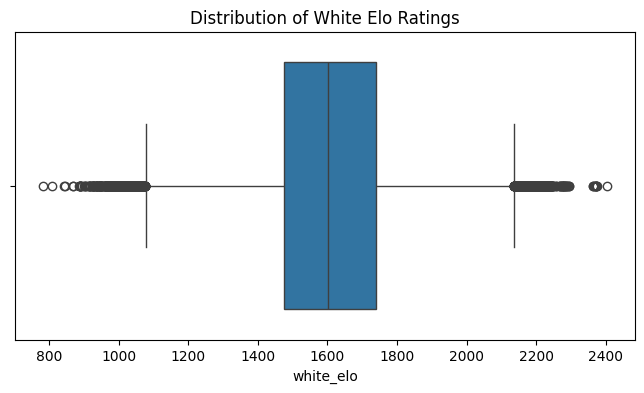

Number of outlier ratings: 1209
Outlier range: <1076.5 or >2136.5


In [8]:
# Get rating distribution from fact_games (White Elo)
query = "SELECT white_elo FROM fact_games WHERE white_elo IS NOT NULL"
ratings = pd.read_sql(query, conn)

# Box plot
plt.figure(figsize=(8,4))
sns.boxplot(x=ratings['white_elo'])
plt.title('Distribution of White Elo Ratings')
plt.show()

# IQR method to detect outliers
Q1 = ratings['white_elo'].quantile(0.25)
Q3 = ratings['white_elo'].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5*IQR
upper = Q3 + 1.5*IQR
outliers = ratings[(ratings['white_elo'] < lower) | (ratings['white_elo'] > upper)]
print(f"Number of outlier ratings: {len(outliers)}")
print(f"Outlier range: <{lower} or >{upper}")

# Distribution

/tmp/ipykernel_268276/1803857868.py:8: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  res = pd.read_sql("SELECT y_true FROM batch_predictions", conn)


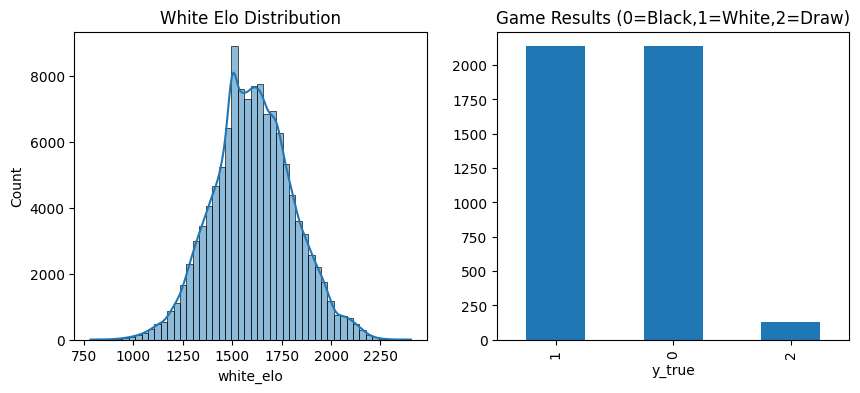

In [9]:
# Histogram of White Elo
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
sns.histplot(ratings['white_elo'], bins=50, kde=True)
plt.title('White Elo Distribution')

# Distribution of game result (from batch_predictions)
res = pd.read_sql("SELECT y_true FROM batch_predictions", conn)
plt.subplot(1,2,2)
res['y_true'].value_counts().plot(kind='bar')
plt.title('Game Results (0=Black,1=White,2=Draw)')
plt.show()

# Relationship between features

/tmp/ipykernel_268276/112716115.py:8: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


ValueError: could not convert string to float: '600+8'

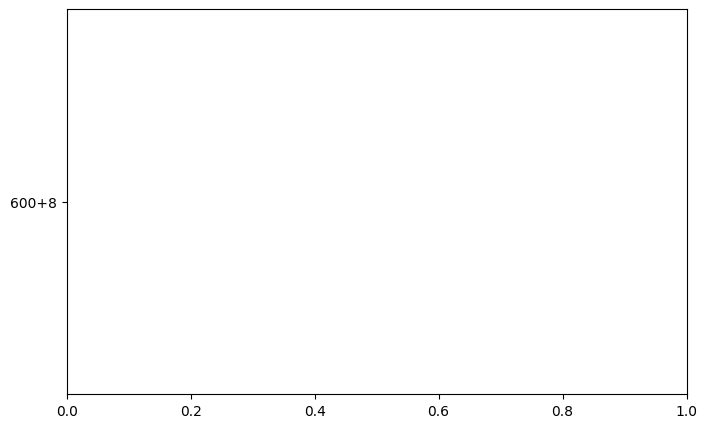

In [12]:
# Create rating difference (requires joining fact_games with dim_player? 
# But fact_games may already have white_elo and black_elo)
query = """
SELECT white_elo, black_elo, time_control 
FROM fact_games 
WHERE white_elo IS NOT NULL AND black_elo IS NOT NULL
"""
df = pd.read_sql(query, conn)
df['rating_diff'] = df['white_elo'] - df['black_elo']

# Scatter plot (or hexbin for large data)
plt.figure(figsize=(8,5))
plt.hexbin(df['rating_diff'], df['time_control'], gridsize=30, cmap='Blues')
plt.xlabel('Rating Difference (White - Black)')
plt.ylabel('Time Control')
plt.colorbar(label='Count')
plt.title('No strong correlation – players of all levels play all time controls')
plt.show()

In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

query = """
SELECT white_elo, black_elo, time_control 
FROM fact_games 
WHERE white_elo IS NOT NULL AND black_elo IS NOT NULL
  AND time_control IS NOT NULL
"""
df = pd.read_sql(query, conn)

# Convert time_control from "minutes+increment" to total seconds
def parse_time_control(tc):
    if '+' in tc:
        mins, inc = tc.split('+')
        total_seconds = int(mins)*60 + int(inc)
    else:
        total_seconds = int(tc)*60
    return total_seconds

df['time_control_seconds'] = df['time_control'].apply(parse_time_control)
df['rating_diff'] = df['white_elo'] - df['black_elo']

# Hexbin plot
plt.figure(figsize=(8,5))
hb = plt.hexbin(df['rating_diff'], df['time_control_seconds'], gridsize=30, cmap='Blues')
plt.xlabel('Rating Difference (White - Black)')
plt.ylabel('Time Control (seconds)')
plt.colorbar(hb, label='Count')
plt.title('No strong correlation – players of all levels play all time controls')
plt.show()

/tmp/ipykernel_268276/731310329.py:11: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


ValueError: invalid literal for int() with base 10: '-'

/tmp/ipykernel_268276/2744091178.py:2: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  sample = pd.read_sql("SELECT result FROM fact_games LIMIT 1", conn)
/tmp/ipykernel_268276/2744091178.py:19: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


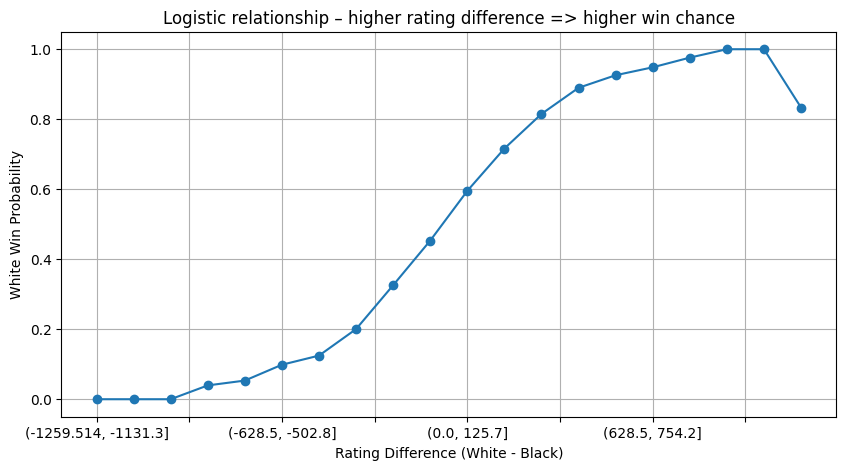

In [17]:
# Auto-detect result format
sample = pd.read_sql("SELECT result FROM fact_games LIMIT 1", conn)
first_val = sample.iloc[0,0]

if isinstance(first_val, str):
    # Map strings to numeric
    result_map = {
        '1-0': 1,      # White win
        '0-1': 0,      # Black win
        '1/2-1/2': 2,  # Draw
        '½-½': 2
    }
    # Create a new column with numeric result
    query = """
    SELECT white_elo, black_elo, result 
    FROM fact_games 
    WHERE white_elo IS NOT NULL AND black_elo IS NOT NULL
    """
    df = pd.read_sql(query, conn)
    df['result_num'] = df['result'].map(result_map)
    # Filter out draws (result_num == 2)
    df = df[df['result_num'].isin([0,1])].copy()
    df['white_win'] = (df['result_num'] == 1).astype(int)
else:
    # Assume integer values (0=Black win, 1=White win, 2=Draw)
    query = """
    SELECT white_elo, black_elo, result 
    FROM fact_games 
    WHERE white_elo IS NOT NULL AND black_elo IS NOT NULL
      AND result IN (0,1)
    """
    df = pd.read_sql(query, conn)
    df['white_win'] = df['result']  # result already 1 for White win

df['rating_diff'] = df['white_elo'] - df['black_elo']

# Bin rating difference
df['diff_bin'] = pd.cut(df['rating_diff'], bins=20)
win_rate = df.groupby('diff_bin')['white_win'].mean()

# Plot
plt.figure(figsize=(10,5))
win_rate.plot(kind='line', marker='o')
plt.xlabel('Rating Difference (White - Black)')
plt.ylabel('White Win Probability')
plt.title('Logistic relationship – higher rating difference => higher win chance')
plt.grid(True)
plt.show()

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr

# Query numeric columns from fact_games
query = """
SELECT 
    white_elo, 
    black_elo, 
    CASE 
        WHEN result = '1-0' THEN 1 
        WHEN result = '0-1' THEN 0 
        ELSE NULL 
    END as white_win,
    time_control
FROM fact_games 
WHERE white_elo IS NOT NULL AND black_elo IS NOT NULL
  AND result IN ('1-0','0-1')
LIMIT 50000
"""
df = pd.read_sql(query, conn)

# Parse time control to seconds
def parse_tc(tc):
    if '+' in tc:
        mins, inc = tc.split('+')
        return int(mins)*60 + int(inc)
    return int(tc)*60
df['time_control_sec'] = df['time_control'].apply(parse_tc)
df['rating_diff'] = df['white_elo'] - df['black_elo']

# Select numeric columns for correlation
corr_df = df[['white_elo', 'black_elo', 'rating_diff', 'time_control_sec', 'white_win']]

# Compute correlation matrix
corr_matrix = corr_df.corr(method='pearson')

# Plot heatmap
plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, 
            square=True, linewidths=0.5, fmt='.2f')
plt.title('Correlation Heatmap of Numeric Features', fontsize=14)
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=300)
plt.show()

/tmp/ipykernel_268276/2096702074.py:23: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


ValueError: invalid literal for int() with base 10: '-'

/tmp/ipykernel_268276/1483558027.py:16: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


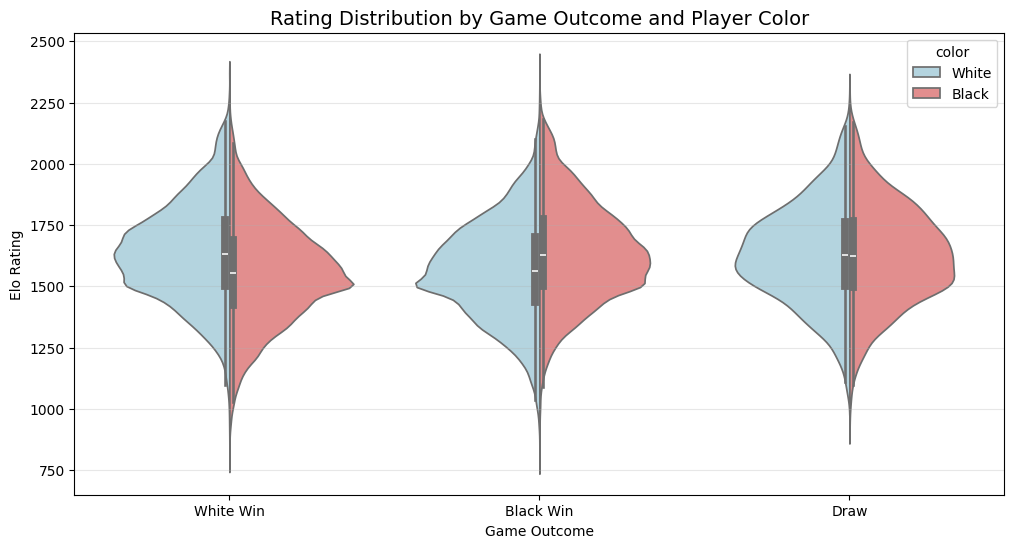

In [19]:
# Get rating data with outcome
query = """
SELECT 
    white_elo, 
    black_elo, 
    CASE 
        WHEN result = '1-0' THEN 'White Win'
        WHEN result = '0-1' THEN 'Black Win'
        WHEN result = '1/2-1/2' THEN 'Draw'
    END as outcome
FROM fact_games 
WHERE white_elo IS NOT NULL AND black_elo IS NOT NULL
  AND result IN ('1-0','0-1','1/2-1/2')
LIMIT 100000
"""
df = pd.read_sql(query, conn)

# Reshape to long format for seaborn
white_df = df[['white_elo', 'outcome']].rename(columns={'white_elo': 'rating'})
white_df['color'] = 'White'
black_df = df[['black_elo', 'outcome']].rename(columns={'black_elo': 'rating'})
black_df['color'] = 'Black'
long_df = pd.concat([white_df, black_df], ignore_index=True)

plt.figure(figsize=(12,6))
sns.violinplot(data=long_df, x='outcome', y='rating', hue='color', 
               split=True, palette={'White':'lightblue', 'Black':'lightcoral'})
plt.title('Rating Distribution by Game Outcome and Player Color', fontsize=14)
plt.ylabel('Elo Rating')
plt.xlabel('Game Outcome')
plt.grid(axis='y', alpha=0.3)
plt.savefig('violin_rating_outcome.png', dpi=300)
plt.show()

In [31]:
cursor.execute("DESCRIBE fact_games;")
for row in cursor.fetchall():
    print(row[0])

game_id
white_player_id
black_player_id
opening_id
date_id
result
white_elo
black_elo
white_rating_diff
black_rating_diff
time_control
termination
event
utc_datetime
move_count
year
month


In [32]:
query = """
SELECT 
    LEFT(o.eco_code, 1) as eco_family,
    COUNT(*) as total_games,
    SUM(CASE WHEN f.result = '1-0' THEN 1 ELSE 0 END) as white_wins,
    SUM(CASE WHEN f.result = '0-1' THEN 1 ELSE 0 END) as black_wins,
    SUM(CASE WHEN f.result = '1/2-1/2' THEN 1 ELSE 0 END) as draws,
    AVG(f.move_count) as avg_moves
FROM fact_games f
JOIN dim_opening o ON f.opening_id = o.opening_id
WHERE o.eco_code IS NOT NULL
GROUP BY LEFT(o.eco_code, 1)
"""
df_radar = pd.read_sql(query, conn)

# Calculate rates
df_radar['white_win_rate'] = df_radar['white_wins'] / df_radar['total_games']
df_radar['black_win_rate'] = df_radar['black_wins'] / df_radar['total_games']
df_radar['draw_rate'] = df_radar['draws'] / df_radar['total_games']

# Normalise avg_moves
max_moves = df_radar['avg_moves'].max()
df_radar['norm_moves'] = df_radar['avg_moves'] / max_moves

# Radar setup
categories = ['White Win Rate', 'Black Win Rate', 'Draw Rate', 'Avg Game Length (norm)']
values = df_radar[['white_win_rate', 'black_win_rate', 'draw_rate', 'norm_moves']].values
eco_families = df_radar['eco_family'].tolist()

angles = np.linspace(0, 2*np.pi, len(categories), endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(figsize=(8,8), subplot_kw=dict(polar=True))
for i, family in enumerate(eco_families):
    vals = values[i].tolist()
    vals += vals[:1]
    ax.plot(angles, vals, 'o-', linewidth=2, label=family)
    ax.fill(angles, vals, alpha=0.1)
ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories)
ax.set_ylim(0,1)
ax.legend(loc='upper right', bbox_to_anchor=(1.3,1.0))
plt.title('Opening Family Performance Radar')
plt.tight_layout()
plt.savefig('radar_eco.png', dpi=300)
plt.show()

/tmp/ipykernel_268276/1192240938.py:14: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_radar = pd.read_sql(query, conn)


ProgrammingError: 1054 (42S22): Unknown column 'o.eco_code' in 'field list'

In [27]:
cursor.execute("SELECT DISTINCT time_control FROM fact_games LIMIT 50;")
for row in cursor.fetchall():
    print(row[0])

600+8
480+2
420+17
60+1
300+3
300+0
540+0
900+0
180+5
300+8
420+0
360+6
1200+0
1560+30
300+2
300+5
60+0
480+8
180+15
240+0
420+9
480+0
180+3
660+0
180+0
0+1
600+5
600+3
120+0
300+4
720+0
300+1
120+2
600+10
120+3
600+6
360+2
-
1800+8
420+3
480+16
840+0
1320+8
600+0
300+9
300+12
180+1
120+1
240+4
900+10


/tmp/ipykernel_268276/2421720119.py:41: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_term = pd.read_sql(query, conn)


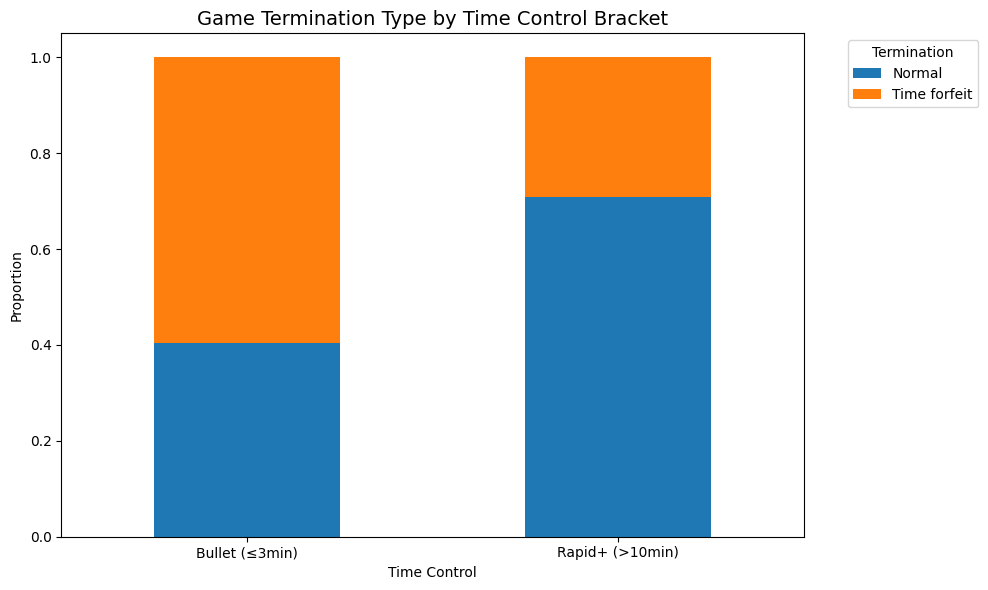

In [28]:
import pandas as pd
import matplotlib.pyplot as plt

# -------------------------------------------------------------------
# Safe time_control parser (handles '-', None, malformed)
# -------------------------------------------------------------------
def parse_time_control_safe(tc):
    if tc is None or tc == '-' or tc == '?' or tc == '':
        return None
    try:
        if '+' in tc:
            mins, inc = tc.split('+')
            total_seconds = int(mins) * 60 + int(inc)
        else:
            total_seconds = int(tc) * 60
        return total_seconds
    except (ValueError, TypeError):
        return None

# -------------------------------------------------------------------
# Classify into brackets
# -------------------------------------------------------------------
def tc_bracket_sec(sec):
    if sec <= 180:          # ≤3 minutes
        return 'Bullet (≤3min)'
    elif sec <= 600:        # 3–10 minutes
        return 'Blitz (3-10min)'
    else:
        return 'Rapid+ (>10min)'

# -------------------------------------------------------------------
# Query data from fact_games
# -------------------------------------------------------------------
query = """
SELECT termination, time_control
FROM fact_games
WHERE termination IS NOT NULL
  AND time_control IS NOT NULL
LIMIT 200000
"""
df_term = pd.read_sql(query, conn)

# Parse time control
df_term['time_control_sec'] = df_term['time_control'].apply(parse_time_control_safe)

# Drop rows where parsing failed (e.g., dash '-')
df_term = df_term.dropna(subset=['time_control_sec'])

# Assign bracket
df_term['tc_bracket'] = df_term['time_control_sec'].apply(tc_bracket_sec)

# -------------------------------------------------------------------
# Create stacked bar chart (normalised)
# -------------------------------------------------------------------
term_ct = pd.crosstab(df_term['tc_bracket'], df_term['termination'], normalize='index')

# Plot
ax = term_ct.plot(kind='bar', stacked=True, figsize=(10,6),
                  color=['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728'])
ax.set_title('Game Termination Type by Time Control Bracket', fontsize=14)
ax.set_ylabel('Proportion')
ax.set_xlabel('Time Control')
ax.legend(title='Termination', bbox_to_anchor=(1.05, 1))
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
plt.tight_layout()
plt.savefig('stacked_termination.png', dpi=300)
plt.show()

/tmp/ipykernel_268276/193373930.py:5: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_pred = pd.read_sql(query, conn)


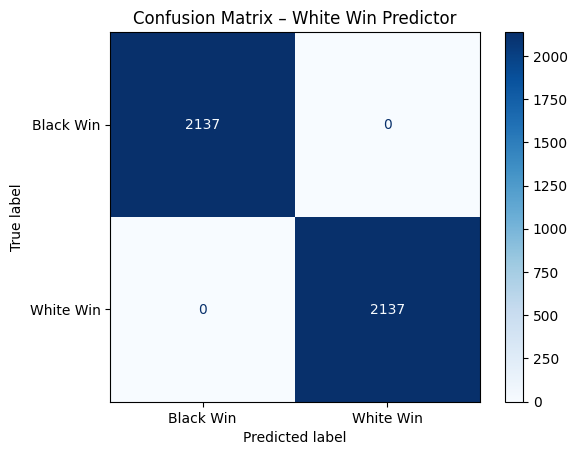

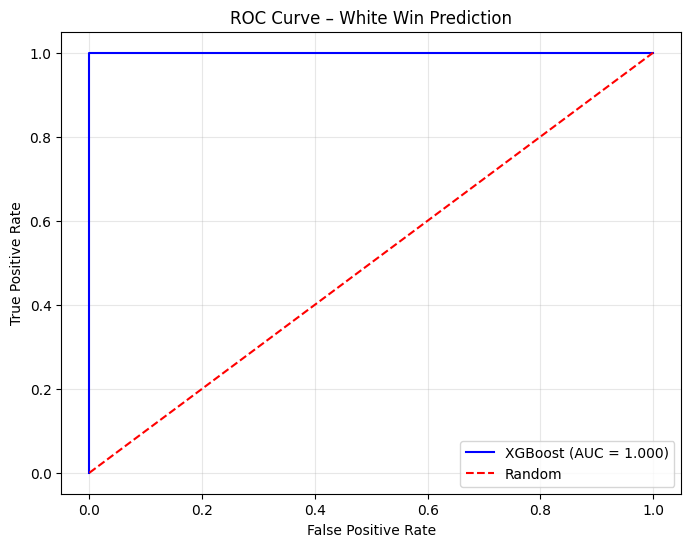

In [25]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc
import matplotlib.pyplot as plt

query = "SELECT y_true, y_pred, prob_win FROM batch_predictions WHERE y_true IN (0,1)"
df_pred = pd.read_sql(query, conn)

# Confusion matrix
cm = confusion_matrix(df_pred['y_true'], df_pred['y_pred'])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Black Win', 'White Win'])
disp.plot(cmap='Blues')
plt.title('Confusion Matrix – White Win Predictor')
plt.savefig('confusion_matrix.png', dpi=300)
plt.show()

# ROC Curve
fpr, tpr, _ = roc_curve(df_pred['y_true'], df_pred['prob_win'])
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, 'b-', label=f'XGBoost (AUC = {roc_auc:.3f})')
plt.plot([0,1], [0,1], 'r--', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve – White Win Prediction')
plt.legend()
plt.grid(alpha=0.3)
plt.savefig('roc_curve.png', dpi=300)
plt.show()

/tmp/ipykernel_268276/2995831502.py:11: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_drift = pd.read_sql(query, conn)


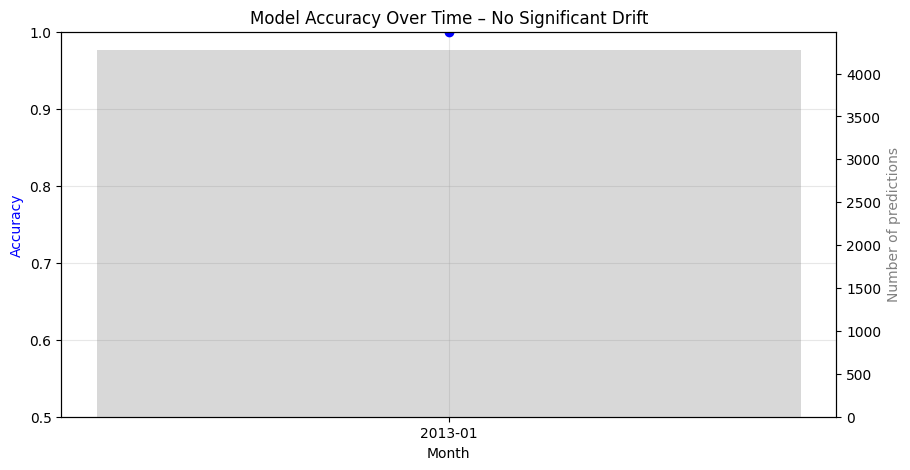

In [33]:
query = """
SELECT 
    month, 
    AVG(CASE WHEN y_true = y_pred THEN 1 ELSE 0 END) as accuracy,
    COUNT(*) as n_predictions
FROM batch_predictions
WHERE y_true IN (0,1)
GROUP BY month
ORDER BY month
"""
df_drift = pd.read_sql(query, conn)

fig, ax1 = plt.subplots(figsize=(10,5))
ax1.plot(df_drift['month'], df_drift['accuracy'], 'b-o', label='Accuracy')
ax1.set_xlabel('Month')
ax1.set_ylabel('Accuracy', color='b')
ax1.set_ylim(0.5, 1.0)
ax1.grid(True, alpha=0.3)

ax2 = ax1.twinx()
ax2.bar(df_drift['month'], df_drift['n_predictions'], alpha=0.3, color='gray', label='Volume')
ax2.set_ylabel('Number of predictions', color='gray')

plt.title('Model Accuracy Over Time – No Significant Drift')
plt.savefig('drift_accuracy.png', dpi=300)
plt.show()